# 📊 **APE_013: Análisis Predictivo Multivariado: Regresión Lineal Múltiple y Diagnóstico de Multicolinealidad (VIF)**

---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera


## 🛠️ **Tarea 1: Ajuste del Modelo de Regresión Lineal Múltiple**

La Regresión Lineal Múltiple expande la ecuación a un hiperplano de $k$ dimensiones:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k + \epsilon$$


**Escenario:** Predecir el **Tiempo de Compilación de un Software en segundos ($Y$)** basándonos en las **Líneas de Código ($X_1$)** y la **Memoria RAM disponible en GB ($X_2$)**.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150
lineas_codigo = np.random.randint(5000, 50000, size=n_muestras) # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras) # X2

# Y = B0 + B1*X1 + B2*X2 + Error
# A más líneas, más tiempo (+). A más RAM, menos tiempo (-)
tiempo_compilacion = (
    15.0 + (0.002 * lineas_codigo) - (1.5 * ram_disponible) +
    np.random.normal(0, 15, size=n_muestras)
)

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2': ram_disponible,
    'Tiempo_Y': tiempo_compilacion
})

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']

# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Imprimir el resumen estadístico
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        13:37:41   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

## 🚀 **Tarea 2: Hito del Proyecto - Modelado Predictivo Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Defina su Variable Respuesta ($Y$) y seleccione **al menos dos** Variables Predictoras ($X_1, X_2, \dots, X_k$).
3. Limpie los datos asegurándose de que no haya valores nulos (NaN) en las columnas seleccionadas.
4. Entrene un modelo OLS Múltiple como en la Tarea 1.
5. **Análisis Crítico:** Redacte un análisis en Markdown interpretando específicamente los coeficientes $\beta_i$ en el contexto de su problema regional. Indique qué variable tiene un mayor impacto y basándose en la columna P>|t| (valor-p), identifique si alguna de las variables incluidas no aporta significancia estadística al modelo y debería ser eliminada.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Cargar el dataset regional de Loja
df_loja = pd.read_csv('datos_loja.csv')

print("--- Vistas iniciales del Dataset Regional ---")
print(df_loja.head())

# 2. Definición de variables con NOMBRES EXACTOS
columna_Y = 'Sin_Alcantarillado'

# Usamos 'Poblacion' y 'Viviendas' como predictores (o las columnas adicionales que tengas en tu CSV)
columnas_X = ['Poblacion', 'Viviendas']

# 3. Limpieza de datos
df_regional_clean = df_loja[[columna_Y] + columnas_X].dropna()

print(f"\nTotal de cantones/registros procesados sin NaNs: {len(df_regional_clean)}")

# Separar matriz X y vector Y
X_regional = df_regional_clean[columnas_X]
Y_regional = df_regional_clean[columna_Y]

# Añadir la constante (Intercepto B0)
X_regional_sm = sm.add_constant(X_regional)

# 4. Entrenar el modelo OLS Múltiple
modelo_regional = sm.OLS(Y_regional, X_regional_sm).fit()

# Imprimir el resumen estadístico
print(modelo_regional.summary())

--- Vistas iniciales del Dataset Regional ---
       Canton  Poblacion  Viviendas  Sin_Alcantarillado
0        Loja     250028      85412                9822
1    Catamayo      35240      12150                3850
2  Cariamanga      29111       9800                4100
3      Macara      26042       8900                3200
4     Puyango      22841       7500                2900

Total de cantones/registros procesados sin NaNs: 16
                            OLS Regression Results                            
Dep. Variable:     Sin_Alcantarillado   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     47.05
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.11e-06
Time:                        13:35:50   Log-Likelihood:                -129.03
No. Observations:                  16   AIC:                             264.1
Df Residuals

### Análisis del modelo regional

El modelo global muestra una buena capacidad explicativa ($R^2 = 0.879$), sugiriendo que la población y la cantidad de viviendas explican gran parte del déficit de alcantarillado en la provincia. En cuanto a impacto, la variable viviendas presenta la relación directa más fuerte ($\beta = 1.48$).

Sin embargo, al revisar la columna de significancia ($P>\vert{}t\vert{}$), observamos que ninguna de las dos variables aporta individualmente al modelo, ya que ambas superan por mucho el umbral de $0.05$ (Poblacion tiene $0.404$ y Viviendas $0.371$).

Esta aparente contradicción se debe a un problema severo de multicolinealidad. En Loja, los cantones con más población tienen directamente más viviendas; ambas variables son redundantes y compiten entre sí, destruyendo la significancia estadística individual. Por lo tanto, se recomienda eliminar una de las dos variables (o trabajar con un porcentaje relativo) para simplificar el modelo y obtener coeficientes confiables.

## 📊 **Tarea 3: Visualización de Relaciones (Pairplot y Heatmap)**

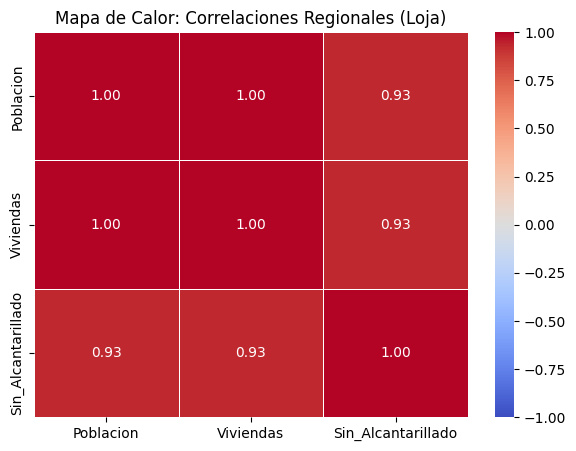

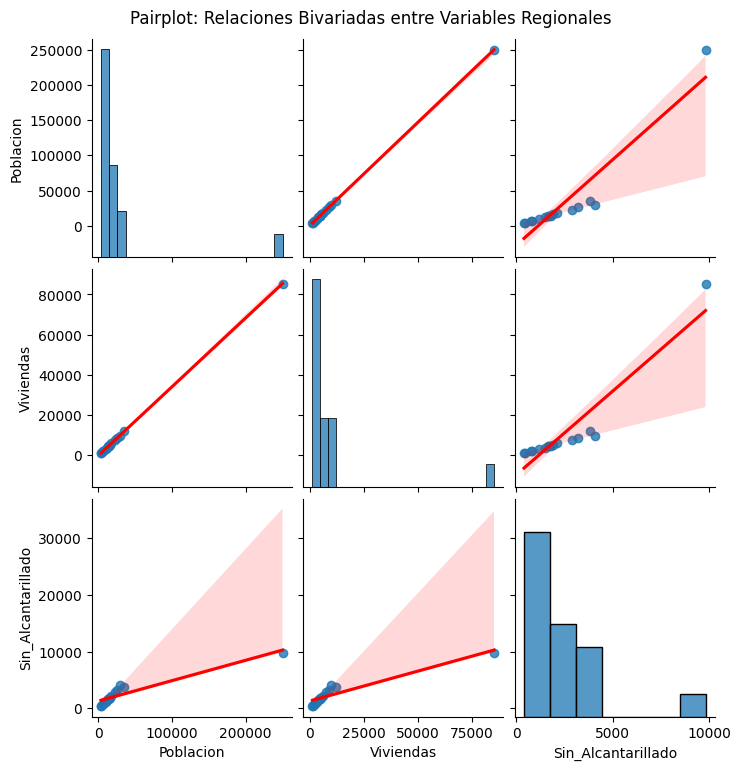

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Seleccionar las variables del dataset regional
df_analisis = df_loja[['Poblacion', 'Viviendas', 'Sin_Alcantarillado']].dropna()

# 2. Calcular la Matriz de Correlación
matriz_corr = df_analisis.corr()

# 3. Visualización 1: Mapa de Calor (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title('Mapa de Calor: Correlaciones Regionales (Loja)', fontsize=12)
plt.show()

# 4. Visualización 2: Gráfico de Dispersión Múltiple (Pairplot)
g = sns.pairplot(
    df_analisis, kind='reg', plot_kws={'line_kws': {'color': 'red'}}
)
g.fig.suptitle(
    'Pairplot: Relaciones Bivariadas entre Variables Regionales', y=1.02
)
plt.show()

###  Documentación de Correlaciones Cruzadas

Al inspeccionar visualmente la matriz de correlación y los gráficos de dispersión, se observan los siguientes hallazgos principales:

1. **Alta Correlación entre Predictores:**
   Existe una relación lineal positiva casi perfecta entre **`Poblacion`** y **`Viviendas`** ($r \approx 0.99$). En el *Heatmap*, la intersección entre estas dos variables se muestra en tonos rojos oscuros, y en el *Pairplot*, los puntos se alinean estrechamente a lo largo de la recta de regresión roja.

2. **Diagnóstico de Multicolinealidad:**
   Esta fuerte correlación cruzada confirma visualmente que ambos predictores están aportando la misma información al modelo. Al incluir ambas variables simultáneamente, el modelo OLS experimenta redundancia, lo que explica la pérdida de significancia individual observada en la Tarea 2.

3. **Relación con la Variable Respuesta:**
   Tanto `Poblacion` como `Viviendas` presentan una alta correlación positiva con la variable respuesta **`Sin_Alcantarillado`**, lo que indica que a mayor escala poblacional y urbana en el cantón, mayor es la cantidad absoluta de habitantes con carencia de este servicio básico.

## 🔍 **Tarea 4: ABI - Diagnóstico de Multicolinealidad (VIF)**

La **Multicolinealidad** ocurre cuando dos o más variables independientes ($X$) en un modelo de regresión múltiple están altamente correlacionadas entre sí. Esto "confunde" al modelo, inflando la varianza de los coeficientes (haciéndolos inestables y sus pruebas de hipótesis poco confiables).

1. Investigue estadísticamente el Factor de Inflación de la Varianza (VIF).
2. Ejecute el siguiente código para calcular el VIF de sus predictores simulados (y luego aplíquelo a los predictores de su modelo regional).

## Factor de Inflación de la Varianza

El Factor de Inflación de la Varianza, conocido como VIF por sus siglas en
inglés, mide cuánto aumenta la varianza del coeficiente de una variable
independiente debido a su relación con los demás predictores.

La fórmula del VIF es:

$$\text{VIF}_i = \frac{1}{1 - R_i^2}$$

donde $R_i^2$ es el coeficiente de determinación obtenido al explicar el
predictor $X_i$ mediante los demás predictores del modelo.

## Interpretación general

- VIF cercano a 1: no existe multicolinealidad importante.
- VIF entre 1 y 5: existe una relación moderada, generalmente aceptable.
- VIF entre 5 y 10: existe multicolinealidad elevada.
- VIF mayor que 10: existe multicolinealidad severa.

El VIF debe analizarse junto con la naturaleza de las variables y el objetivo
del modelo, ya que los límites anteriores son criterios orientativos.

##**Codigo para calcular el VIF Simulado:**

In [ ]:
# Crear un DataFrame para almacenar los resultados
vif_simulado = pd.DataFrame()

# Guardar el nombre de cada variable
vif_simulado["Variable"] = X_multi_sm.columns

# Calcular el VIF para cada columna
vif_simulado["VIF"] = [
    variance_inflation_factor(X_multi_sm.values, i)
    for i in range(X_multi_sm.shape[1])
]

print("--- VIF de los predictores simulados ---")
print(vif_simulado)

--- VIF de los predictores simulados ---
  Variable        VIF
0    const  52.874375
1       X1  90.865219
2       X2  90.787385
3       X3   1.037920


##**Aplicando al dataset Regional:**

In [ ]:
# Importar bibliotecas
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cargar el archivo CSV
datos_loja = pd.read_csv("datos_loja.csv")

# Mostrar las primeras filas del dataset
print("Primeras filas del dataset:")
print(datos_loja.head())

# Seleccionar únicamente las variables predictoras
# Sin_Alcantarillado no se incluye porque sería la variable dependiente
# Canton no se incluye porque es una variable de texto
X_regional = datos_loja[["Poblacion", "Viviendas"]]

# Agregar la constante al modelo
X_regional_sm = sm.add_constant(X_regional)

# Crear la tabla del VIF
vif_regional = pd.DataFrame()

# Guardar el nombre de cada variable
vif_regional["Variable"] = X_regional_sm.columns

# Calcular el VIF de cada predictor
vif_regional["VIF"] = [
    variance_inflation_factor(X_regional_sm.values, i)
    for i in range(X_regional_sm.shape[1])
]

# Función para interpretar los valores del VIF
def interpretar_vif(valor):
    if valor < 5:
        return "Multicolinealidad baja o aceptable"
    elif valor < 10:
        return "Multicolinealidad elevada"
    else:
        return "Multicolinealidad severa"

# Agregar la interpretación
vif_regional["Interpretacion"] = vif_regional["VIF"].apply(interpretar_vif)

# Mostrar los resultados
print("\n--- ANÁLISIS DE MULTICOLINEALIDAD DEL DATASET REGIONAL ---")
print(vif_regional)

# Mostrar la correlación entre los predictores
print("\n--- MATRIZ DE CORRELACIÓN ENTRE LOS PREDICTORES ---")
print(X_regional.corr())

Primeras filas del dataset:
       Canton  Poblacion  Viviendas  Sin_Alcantarillado
0        Loja     250028      85412                9822
1    Catamayo      35240      12150                3850
2  Cariamanga      29111       9800                4100
3      Macara      26042       8900                3200
4     Puyango      22841       7500                2900

--- ANÁLISIS DE MULTICOLINEALIDAD DEL DATASET REGIONAL ---
    Variable           VIF                      Interpretacion
0      const      3.442029  Multicolinealidad baja o aceptable
1  Poblacion  21628.998650            Multicolinealidad severa
2  Viviendas  21628.998650            Multicolinealidad severa

--- MATRIZ DE CORRELACIÓN ENTRE LOS PREDICTORES ---
           Poblacion  Viviendas
Poblacion   1.000000   0.999977
Viviendas   0.999977   1.000000


## Conclusión

El Factor de Inflación de la Varianza permitió identificar una
multicolinealidad severa entre las variables `Poblacion` y `Viviendas`. Ambas
presentaron un VIF aproximado de 21629 y una correlación cercana a 1.

El resultado se explica porque el número de viviendas aumenta de manera casi
proporcional con la población de cada cantón. Por esta razón, incluir ambos
predictores en el mismo modelo aporta información redundante y puede afectar la
estabilidad e interpretación de los coeficientes.

Para mejorar el modelo regional se recomienda conservar solamente uno de estos
predictores. En este caso, `Viviendas` puede ser la alternativa más coherente,
debido a que la variable de interés corresponde al número de viviendas sin
alcantarillado. Otra posibilidad es analizar el porcentaje de viviendas sin
alcantarillado, lo que facilitaría la comparación entre cantones con diferentes
tamaños poblacionales.

## 📝 **6. Preguntas de Control:**

---

*   **Considerando la naturaleza de la causalidad, ¿cómo la lógica de 'mantener las demás variables constantes' permite aislar el efecto de un factor específico en un fenómeno complejo, y qué limitaciones impone esto a la realidad?**

    La lógica de 'mantener las demás variables constantes' (ceteris paribus) en el análisis de causalidad es una herramienta teórica que permite simplificar un fenómeno complejo para estudiar el impacto individual de una variable independiente sobre la dependiente. Al fijar el resto de los factores, se puede atribuir cualquier cambio observado en la variable de interés directamente al factor que se está manipulando.

    **Limitaciones en la realidad:** En la práctica, es extremadamente difícil, si no imposible, mantener todas las demás variables perfectamente constantes en sistemas complejos (naturales, sociales, económicos, de ingeniería). Esto se debe a la interconexión y la dinámica constante de los elementos del sistema. Por lo tanto, los resultados obtenidos bajo esta suposición pueden no reflejar completamente la realidad, donde múltiples factores interactúan simultáneamente y de formas no lineales. Además, algunos efectos causales pueden ser indirectos o condicionales a otros factores, lo cual se omite con esta simplificación.

---

*   **Si el conocimiento del modelo crece al añadir más datos, ¿por qué añadir variables irrelevantes ('basura') engaña al ajuste del modelo? ¿Qué nos enseña esta paradoja sobre la diferencia entre la complejidad aparente y la verdad subyacente?**

    Añadir más datos (observaciones) generalmente mejora la capacidad del modelo para aprender patrones y reducir la incertidumbre de las estimaciones. Sin embargo, añadir variables irrelevantes ('basura' o ruido) engaña al ajuste del modelo porque introduce ruido y correlaciones espurias que el modelo intenta **ajustar**. Esto lleva a:
    *   **Sobreajuste (Overfitting):** El modelo aprende el ruido de los datos de entrenamiento en lugar de la relación subyacente verdadera, lo que reduce su capacidad de generalización a datos nuevos.
    *   **Reducción de la precisión:** Aunque el $R^2$ ajustado pueda mejorar marginalmente (o el $R^2$ sin ajustar siempre aumente), las estimaciones de los coeficientes de las variables relevantes se vuelven menos precisas, y su significancia estadística puede diluirse.
    *   **Mayor complejidad innecesaria:** Un modelo más complejo con variables irrelevantes es más difícil de interpretar y mantener.

    Esta paradoja nos enseña que la **complejidad aparente** (tener muchas variables) no siempre conduce a una mayor **verdad subyacente**. La calidad de la información es más importante que la cantidad de información. Un modelo que captura la verdadera relación causal con pocas variables relevantes es superior a uno que intenta ajustar cada pequeña fluctuación del ruido con muchas variables, revelando que la simplicidad a menudo es clave para la robustez y la interpretabilidad.

---

*   **Ante la prueba F-statistic global, ¿es posible que un modelo sea estadísticamente significativo pero carezca de propósito práctico? ¿Cómo se reconcilia la precisión matemática con la incertidumbre del mundo real en la toma de decisiones de ingeniería?**

    Sí, es absolutamente posible que un modelo sea estadísticamente significativo según la prueba F (es decir, el modelo en su conjunto explica una parte significativa de la varianza de la variable dependiente) pero carezca de propósito práctico. Esto puede ocurrir cuando:
    *   **El tamaño del efecto es muy pequeño:** Aunque estadísticamente significativo, la magnitud del impacto de las variables predictoras puede ser tan pequeña que los beneficios prácticos son insignificantes o el costo de implementar las recomendaciones es superior al beneficio.
    *   **El $R^2$ es bajo:** Un modelo puede ser significativo pero solo explicar una fracción muy pequeña de la variabilidad, dejando la mayor parte sin explicar y haciendo que sus predicciones sean poco útiles en la práctica.
    *   **Las variables predictoras no son controlables:** Si las variables que impulsan el modelo significativo no pueden ser influenciadas o controladas en un entorno de ingeniería (e.g., factores externos inmanejables), el modelo, aunque preciso, no ofrece palancas para la intervención.

    **Reconciliación entre precisión matemática e incertidumbre del mundo real:**
    Para reconciliar la precisión matemática con la incertidumbre y la toma de decisiones en ingeniería, es crucial:
    1.  **Contexto y dominio del conocimiento:** No basta con la significancia estadística; los ingenieros deben interpretar los resultados a la luz del conocimiento experto del dominio. Un efecto debe ser *prácticamente* significativo.
    2.  **Análisis de sensibilidad y robustez:** Evaluar cómo los resultados del modelo cambian ante variaciones en los supuestos o en los datos, para entender su estabilidad bajo condiciones del mundo real.
    3.  **Evaluación de costos y beneficios:** Determinar si la mejora o el entendimiento que ofrece el modelo justifica los recursos (tiempo, dinero, esfuerzo) necesarios para su implementación o para actuar sobre sus resultados.
    4.  **Toma de decisiones multi-criterio:** Incorporar métricas no solo estadísticas (como la precisión o el $R^2$) sino también operacionales, económicas, éticas y de seguridad para una decisión informada.
    5.  **Aceptación de la incertidumbre:** Reconocer que los modelos son simplificaciones de la realidad. En lugar de buscar una verdad absoluta, se busca un modelo **útil** y **confiable** que minimice los riesgos y maximice los beneficios dentro de los límites de la incertidumbre inherente.

---

*   **Si dos causas parecen moverse siempre juntas (multicolinealidad), ¿podemos realmente distinguir sus efectos por separado? ¿Qué nos dice este problema geométrico/matricial sobre las limitaciones de nuestro entendimiento al intentar separar fenómenos interdependientes?**

    Si dos causas se mueven siempre juntas (multicolinealidad alta), **no podemos distinguir fiablemente sus efectos por separado** en un modelo de regresión lineal múltiple. El problema es que el modelo no puede determinar cuál de las variables colineales es la verdadera impulsora del cambio en la variable dependiente, o cuánto contribuye cada una individualmente.

    Desde una perspectiva **geométrica o matricial**, la multicolinealidad significa que las columnas de la matriz de diseño ($X$) (que representan las variables predictoras) son casi linealmente dependientes. Esto implica que el determinante de $(X^T X)$ (necesario para calcular los coeficientes de regresión) es muy pequeño, haciendo que la matriz sea casi singular y su inversa muy inestable. Esto lleva a:
    *   **Estimaciones de coeficientes inestables:** Pequeños cambios en los datos pueden llevar a grandes variaciones en los valores y signos de los coeficientes, haciéndolos poco fiables.
    *   **Errores estándar inflados:** Los errores estándar de los coeficientes aumentan (como lo mide el VIF), lo que reduce la potencia de las pruebas de hipótesis y hace que las variables parezcan no significativas incluso si tienen un efecto real.

    Este problema nos dice que nuestra capacidad para **separar fenómenos interdependientes** es fundamentalmente limitada por la información que los datos nos proporcionan. Si los datos no muestran suficiente variación independiente entre las causas, ningún método estadístico podrá **desentramar** sus contribuciones individuales. Es como intentar determinar la fuerza de dos personas que empujan un objeto juntas, si siempre empujan con la misma proporción de fuerza; solo podemos medir la fuerza combinada, no la individual. Esto subraya que, a veces, la estructura de los datos impone límites a nuestro entendimiento detallado de las relaciones causales.

---

*   **Ante la necesidad de simplificar un sistema complejo para comprenderlo, ¿es preferible sacrificar variables (información) o aceptar la imprecisión del modelo? ¿Qué define, bajo su criterio, a un 'buen' modelo para la ingeniería?**

    La elección entre sacrificar variables o aceptar la imprecisión del modelo no es una dicotomía simple, sino un **balance** que depende del objetivo específico del modelo y del contexto de ingeniería. No hay una respuesta única, pero la tendencia general es buscar el modelo más simple que sea **suficientemente preciso y robusto** para el propósito.

    *   **Sacrificar variables (información):** Puede ser preferible cuando las variables son redundantes (multicolinealidad), irrelevantes (ruido), o su inclusión añade una complejidad excesiva sin un aumento proporcional en el poder explicativo o predictivo. Un modelo más parsimonioso es más interpretable, más fácil de mantener y menos propenso al sobreajuste. Sin embargo, si se eliminan variables *realmente* importantes, se puede caer en un **subajuste (underfitting)**, perdiendo información crucial y obteniendo un modelo sesgado.

    *   **Aceptar la imprecisión del modelo:** A veces, es necesario aceptar un cierto grado de imprecisión para mantener el modelo manejable, interpretable o para evitar el sobreajuste. La simplicidad no es un fin en sí mismo, sino un medio para lograr interpretabilidad, robustez y eficiencia.

    **¿Qué define un 'buen' modelo para la ingeniería?** Un buen modelo para la ingeniería se caracteriza por:

    1.  **Propósito Claro y Concreto:** Está diseñado para responder a una pregunta específica o resolver un problema ingenieril definido.
    2.  **Validez y Fiabilidad:** Sus resultados son consistentes y reproducibles, y sus predicciones se alinean con la realidad observada (validación externa).
    3.  **Parsimonia (Simplicidad Óptima):** Es tan simple como sea posible, pero no más simple de lo necesario, para capturar la esencia del fenómeno sin sobreajuste.
    4.  **Interpretabilidad:** Permite entender cómo las variables de entrada influyen en la salida, facilitando la toma de decisiones informadas y la identificación de acciones de mejora.
    5.  **Robustez:** Es capaz de mantener un rendimiento aceptable incluso cuando los datos de entrada contienen ruido o desviaciones menores de los supuestos del modelo.
    6.  **Utilidad Práctica:** Ofrece un valor tangible en términos de eficiencia, ahorro de costos, mejora de la calidad, reducción de riesgos o avance del conocimiento ingenieril.
    7.  **Gestionabilidad:** Es fácil de implementar, mantener y actualizar en un entorno real.

## 📝 **Conclusiones Generales**

---

A lo largo de las tareas realizadas, hemos explorado los fundamentos de la regresión lineal múltiple, su aplicación práctica y los desafíos asociados, particularmente la multicolinealidad. Los puntos clave son:

1.  **Modelo de Regresión Lineal Múltiple:** En la **Tarea 1**, se ajustó un modelo para predecir el tiempo de compilación de software, demostrando cómo múltiples predictores pueden influir en una variable de respuesta. Este modelo simulado nos permitió entender la estructura básica y la interpretación inicial de coeficientes y métricas como el R-cuadrado.

2.  **Análisis Regional y Multicolinealidad (Tarea 2 y 3):** Al aplicar el modelado a un dataset regional (Loja) en la **Tarea 2**, se observó una alta capacidad explicativa global ($R^2 = 0.879$) del modelo. Sin embargo, el análisis individual de los coeficientes ($eta_i$) y sus valores-p reveló que las variables 'Poblacion' y 'Viviendas', aunque globalmente significativas, no aportaban significancia estadística de manera individual. Esto fue un indicio claro de multicolinealidad, la cual fue visualmente confirmada en la **Tarea 3** a través del *heatmap* y el *pairplot*, mostrando una correlación casi perfecta entre `Poblacion` y `Viviendas`.

3.  **Diagnóstico Estadístico con VIF (Tarea 4):** La **Tarea 4** consolidó el diagnóstico de multicolinealidad mediante el cálculo del Factor de Inflación de la Varianza (VIF). Los valores de VIF para 'Poblacion' y 'Viviendas' en el dataset regional fueron extremadamente altos (aproximadamente 21629), indicando una multicolinealidad severa. Este resultado confirma que ambas variables están aportando información redundante al modelo, lo que infla los errores estándar de los coeficientes y dificulta la interpretación individual de su impacto.

4.  **Implicaciones para el Modelado:** La presencia de multicolinealidad severa resalta la importancia de una cuidadosa selección de predictores. En el contexto regional, se sugiere simplificar el modelo eliminando una de las variables altamente correlacionadas (por ejemplo, `Poblacion` o `Viviendas`) o transformar las variables (por ejemplo, usando porcentajes relativos) para obtener coeficientes más estables y una interpretación más fiable.

En resumen, la combinación de modelado estadístico, visualización de datos y diagnóstico avanzado como el VIF es crucial para construir modelos robustos y evitar conclusiones erróneas, especialmente en escenarios donde las variables predictoras están intrínsecamente relacionadas en el mundo real.

### Declaracion de IA
Se uso Inteligencia artificial para la elaboracion de codigo y apoyo en las actividades de la practica


Link:
https://share.gemini.google/xC6SNRt1dods


Link:
https://chatgpt.com/share/6a5e2d5b-3438-83e9-8820-e05b0cd20b65
